In [1]:
import matplotlib.pyplot as plt
import numpy as np

\begin{align}
\partial_t \eta + \partial_x \left( h u \right) + \partial_y \left( h u \right) & = 0 \\
\partial_t u - q h u + \partial_x \left( g \eta + K \right) & = \frac{\tau^x - \epsilon u}{D} + \nu \nabla^2 u \\
\partial_t v + q h v + \partial_y \left( g \eta + K \right) & = \frac{\tau^y - \epsilon v}{D} + \nu \nabla^2 v
\end{align}
where
\begin{align}
h & = D + \eta \\
K & = \frac{1}{2} \left( u^2 + v^2 \right) \\
q & = \frac{ f + \zeta }{ h } \\
\zeta & = \partial_x v - \partial_y u \\
f & = f_o + \beta y
\end{align}

\begin{align}
H^u & = \tilde{ h }^i \overline{ u^n }^i \\
h^* &= h^n - \Delta t \partial_x H^u \\
H^v & = \tilde{ h^* }^i \overline{ v^n }^i \\
h^{n+1} &= h^* - \Delta t \partial_y H^v \\
K^u_{i+1/2} & = \overline{ \max(0,u_i^n)^2 + \min(0,u_{i+1}^n)^2 }^j \\
K^v_{j+1/2} & = \overline{ \max(0,v_j^n)^2 + \min(0,v_{j+1}^n)^2 }^i \\
\frac{ u^{n+1} - u^n }{ \Delta t} - f \frac{v^{n+1} + v^n}{2} & =
\left( \tilde{q}^{j}H^v - f v^n \right) - \partial_x \left( g \eta^{n+1} + K^n \right) + \frac{\tau^x}{D} - \frac{\epsilon u^{n+1}}{D} + \nu \nabla^2 u^n \\
\frac{ v^{n+1} - v^n }{ \Delta t} + f \frac{u^{n+1} + u^n}{2} & =
\left( - \tilde{q}^{j}H^u + f u^n \right) - \partial_y \left( g \eta^{n+1} + K^n \right) + \frac{\tau^y}{D} - \frac{\epsilon v^{n+1}}{D} + \nu \nabla^2 v^n \\
\end{align}

\begin{align}
\left( 1 + \frac{\Delta t \epsilon}{D} \right) u^{n+1} - \frac{\Delta t f}{2} v^{n+1} & = u^* - \frac{\Delta t f}{2} v^n \\
u^* & = u^n + \Delta t
\left( \tilde{q}^{j}H^v - \partial_x \left( g \eta^{n+1} + K^n \right) + \frac{\tau^x}{D} + \nu \nabla^2 u^n \right) \\
\left( 1 + \frac{\Delta t \epsilon}{D} \right) v^{n+1} + \frac{\Delta t f}{2} v^{n+1} & = v^* + \frac{\Delta t f}{2} v^n \\
v^* & = v^n + \Delta t
\left( - \tilde{q}^{j}H^u - \partial_y \left( g \eta^{n+1} + K^n \right) + \frac{\tau^y}{D} + \nu \nabla^2 v^n \right)
\end{align}

In [2]:
class DQSWE:

    def __init__(self, ni, g, Do, Lx, fo, beta, epsilon, hsub=1e-12):
        """
        ni      - Number of cells in i-direction
        g       - Gravity [m s-2]
        Do      - Max depth [m]
        Lx      - Domain width [m]
        fo      - Coriolis [s-1]
        beta    - df/dy [m-1 s-1]
        epsilon - Drag rate [m-1 s-1]
        hsub    - H sub-roundoff [m]
        """
        self.ni = ni
        self.g = g
        self.Do = Do
        self.Lx = Lx
        self.fo = fo
        self.beta = beta
        self.epsilon = epsilon
        self.hsub = hsub
    
        # Grid resolution
        self.dx = Lx / ni # Cell width [m]
        
        # Limit to square domains/grids for now
        self.nj = self.ni
        self.Ly = self.Lx
        self.dy = self.dx

        # Grid
        self.x1, self.y1 = self.dx * ( np.arange(self.ni) + 0.5 ), self.dy * ( np.arange(self.nj) + 0.5 )
        self.x, self.y = np.meshgrid(self.x1, self.y1)

        # Initial conditions and bathymetry
        self.resting_state()
        self.flat_topog()

        # Forcing
        self.zero_forcing()

        # Derived parameters
        self.f = self.fo + self.beta * self.y
        self.cg = np.sqrt( self.g * self.Do )
        if not self.fo==0:
            self.Ld = self.cg / self.fo
        else: self.Ld = None
        print("cg =", self.cg, "[m s-1]")
        print("Ld =", self.Ld, "[m]")
        if not self.beta==0:
            self.Ls = self.epsilon / ( self.beta * self.Do )
        else: self.Ls = None
        print("Scales: Ls=epsilon/D/beta =", self.Ls, "[m]")
        if not self.fo==0:
            print("Res: Ld/dx =",self.Ld / self.dx)
        if not self.beta==0:
            print("Res: Ls/dx =",self.Ls / self.dx)

    def resting_state(self):
        """Set state to resting (u=v=eta=0)"""
        self.u = np.zeros((self.nj,self.ni))
        self.v = np.zeros((self.nj,self.ni))
        self.eta = np.zeros((self.nj,self.ni))
        self.time = 0
        self.iter = 0

    def flat_topog(self):
        """Set bathymetry to flat with no boundaries"""
        self.D = self.Do + 0 * self.x

    def bowl_topog(self):
        """Set bathymetry to bowl shape"""
        self.D = self.Do * np.sin( self.x * np.pi / self.Lx ) * np.sin( self.y * np.pi / self.Ly )
        self.D[0,:] = 0 # Ensure land along southern edge
        self.D[:,0] = 0 # Ensure land along western edge
        self.D[-1,:] = 0 # Ensure land along northern edge
        self.D[:,-1] = 0 # Ensure land along eastern edge

    def zero_forcing(self):
        """Set winds to zero"""
        self.taux = 0 * self.y # zonal wind stress [m2 s-2]
        self.tauy = 0 * self.x # meridional wind stress [m2 s-2]

    def gyre_forcing(self):
        """Set winds to zonal gyre forcing"""
        self.taux = 0.1 * np.sin( self.y * np.pi / self.Ly ) # zonal wind stress [m2 s-2]
        self.tauy = 0 * self.x # meridional wind stress [m2 s-2]

    def run(self, dt, samp, nsamps):
        """
        dt     - Time step [s]
        samp   - Steps between samples [steps]
        nsamps - Number of sample to integrate model [steps*samp]
        """
        print("CFL: dt*epsilon/D =", dt * self.epsilon / self.Do )
        print("CFL: dt*f =", dt * np.abs( self.f.max() ) )
        print("CFL: dt*cg/dx =", dt * self.cg / self.dx)
        nsteps = nsamps * samp
        print("nsteps =", nsteps)
        Trun = nsteps * dt
        print("Time: Trun * fo =", Trun * self.fo)
        print("Time: Trun * ( cg / L ) =", Trun * self.cg / self. Lx)

        u = np.zeros((self.ni, self.nj, nsamps+1))
        v = np.zeros((self.ni, self.nj, nsamps+1))
        eta = np.zeros((self.ni, self.nj, nsamps+1))
        time = np.zeros((nsamps+1))

        u[:,:,0] = M.u.copy()
        v[:,:,0] = M.v.copy()
        eta[:,:,0] = M.eta.copy()
        time[0] = M.time

        nsamp = 0
        for iter in range( 1, nsteps + 1 ):
            M.step( dt )
            if iter % samp ==0:
                nsamp += 1
                u[:,:,nsamp] = M.u.copy()
                v[:,:,nsamp] = M.v.copy()
                eta[:,:,nsamp] = M.eta.copy()
                time[nsamp] = M.time
        return u, v, eta, time

    def step(self, dt):
        """
        dt   - Time step [s]
        """

        # Continuity equation (uses u,v at [n])
        h = self.D + self.eta # Total thickness
        uim1 = np.roll( self.u, +1, axis=1 )
        vjm1 = np.roll( self.v, +1, axis=1 )
        if self.iter % 2==0:
            uw = ( uim1 + self.u ) / 2 # u on western edge
            hu = ( np.maximum( uw, 0 ) * np.roll( h, +1, axis=1 ) + np.minimum( uw, 0 ) * h ) # Upwinded h*u on western edge
            h = h - ( dt / self.dx ) * ( np.roll( hu, -1, axis=1 ) - hu )
            vs = ( vjm1 + self.v ) / 2 # v on southern edge
            hv = ( np.maximum( vs, 0 ) * np.roll( h, +1, axis=0 ) + np.minimum( vs, 0 ) * h ) # Upwinded h*v on southern edge
            self.eta = self.eta - ( dt / self.dy ) * ( np.roll( hv, -1, axis=0 ) - hv )
        else:
            vs = ( np.roll( self.v, +1, axis=1 ) + self.v ) / 2 # v on southern edge
            hv = ( np.maximum( vs, 0 ) * np.roll( h, +1, axis=0 ) + np.minimum( vs, 0 ) * h ) # Upwinded h*v on southern edge
            h = h - ( dt / self.dy ) * ( np.roll( hv, -1, axis=0 ) - hv )
            uw = ( np.roll( self.u, +1, axis=1 ) + self.u ) / 2 # u on western edge
            hu = ( np.maximum( uw, 0 ) * np.roll( h, +1, axis=1 ) + np.minimum( uw, 0 ) * h ) # Upwinded h*u on western edge
            self.eta = self.eta - ( dt / self.dx ) * ( np.roll( hu, -1, axis=1 ) - hu )
        h = self.D + self.eta # Update total thickness???

        # Explicit accelerations
        Ku = np.maximum( uim1, 0 )**2 + np.minimum( self.u, 0 )**2 # Enquist-Oscher u^2 at west edge
        Ku = 0.5 * ( np.roll( Ku, +1, axis=0) + Ku ) # u^2 at south-west corner
        Kv = np.maximum( vjm1, 0 )**2 + np.minimum( self.v, 0 )**2 # Enquist-Oscher v^2 at southern edge
        Kv = 0.5 * ( np.roll( Kv, +1, axis=1) + Kv) # v^2 at south-west corner
        E = 0.5 * ( np.roll( self.eta, +1, axis=1) + self.eta ) # eta at west edge
        E = 0.5 * ( np.roll( E, +1, axis=0) + E ) # eta at south-west corner
        B = E + 0.5 * ( Ku + Kv ) # Potential + KE at south-west corner

        Bx = ( np.roll( B, -1, axis=1) - B ) / self.dx
        Bx = 0.5 * ( np.roll( Bx, -1, axis=0) + Bx )
        By = ( np.roll( B, -1, axis=0) - B ) / self.dx
        By = 0.5 * ( np.roll( By, -1, axis=1) + By )

        hfdt = 0.5 * dt * self.f

        ustar = self.taux / ( self.Do + self.hsub )
        ustar = self.u + dt * ustar + hfdt * self.v
        vstar = self.tauy / ( self.Do + self.hsub )
        vstar = self.v + dt * vstar - hfdt * self.u

        # Coriolis (Crank-Nicholson) and damping (Euler backward) update
        edtp1 = 1. + dt * self.epsilon / ( self.D + self.hsub )
        det = 1. / ( edtp1**2 + hfdt**2 )
        self.u = ( edtp1 * ustar + hfdt * vstar ) * det
        self.v = ( edtp1 * vstar - hfdt * ustar ) * det

        self.time = self.time + dt
        self.iter = self.iter + 1

M = DQSWE(32,
          10., # Gravity [m s-2]
          1000., # Max depth [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          2.e-11, # df/dy [m-1 s-1]
          1.e-3 # Drag rate [m-1 s-1]
          )
M.step(50.)
M.resting_state()
M.gyre_forcing()
M.bowl_topog()

cg = 100.0 [m s-1]
Ld = 1000000.0 [m]
Scales: Ls=epsilon/D/beta = 50000.0 [m]
Res: Ld/dx = 32.0
Res: Ls/dx = 1.6


CFL: dt*epsilon/D = 5e-05
CFL: dt*f = 0.005984375
CFL: dt*cg/dx = 0.16
nsteps = 1000000
Time: Trun * fo = 5000.0
Time: Trun * ( cg / L ) = 5000.0


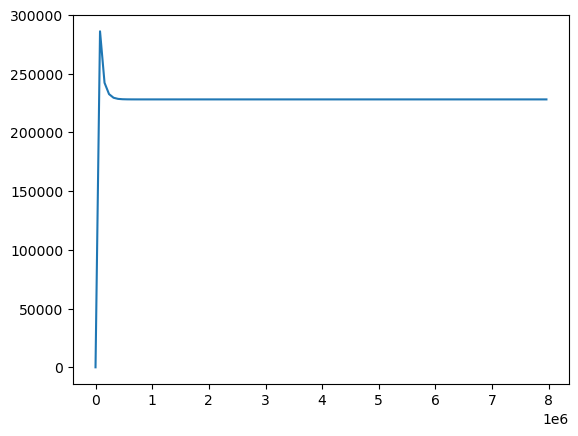

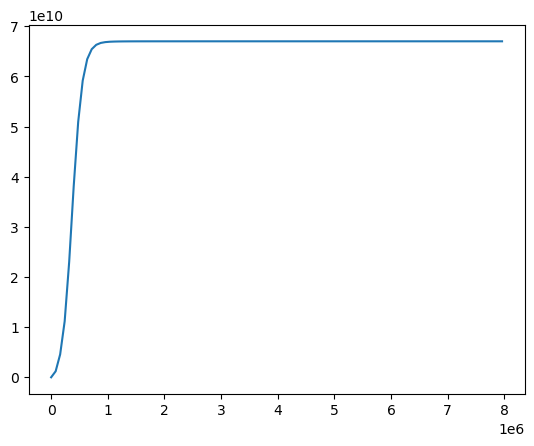

In [3]:
M.resting_state()
u, v, eta, time = M.run(50., 10000, 100)
plt.plot(time / 3.1415/2, np.sum(M.D[:,:,np.newaxis]*(u*u+v*v),axis=(0,1)));
plt.figure();
plt.plot(time / 3.1415/2, np.sum(M.g*eta**2,axis=(0,1)));

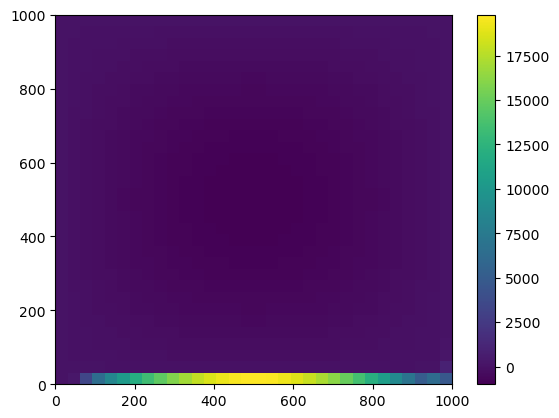

In [4]:
plt.pcolormesh(M.x1/1e3, M.y1/1e3, eta[:,:,10]); plt.colorbar();